# MIMIC-IV Laboratory Events Exploration

Dedicated exploratory analysis of the `labevents` table, including event distribution, top tests, and repetition frequency per admission. Moves lab-specific content out of the consolidated data exploration notebook.

## Section 1: Setup & Configuration

In [29]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from collections import defaultdict, Counter

# Set plot style for better readability
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
# Define file paths for laboratory events
base_path = '~/data/physionet.org/files/mimiciv/3.1/'
labevents_file = base_path + 'hosp/labevents.csv.gz'
d_labitems_file = base_path + 'hosp/d_labitems.csv.gz'
print("File paths set for labevents and d_labitems.")


## Section 2: Laboratory Events Exploration

Analyze laboratory test events. The `labevents` table is large, so we use chunk processing.

In [37]:
# Load d_labitems dictionary for mapping itemid to label
print("Loading d_labitems dictionary...")
d_labitems_df = pd.read_csv(d_labitems_file)
print(f"Total lab items in dictionary: {len(d_labitems_df)}")

# Create mapping from itemid to label
labitem_map = dict(zip(d_labitems_df['itemid'], d_labitems_df['label']))
print(f"Mapping created for {len(labitem_map)} lab items.")

Loading d_labitems dictionary...
Total lab items in dictionary: 1650
Mapping created for 1650 lab items.


In [38]:
# Read labevents in chunks and aggregate (combined analysis)
print("
Reading labevents file in chunks...")
chunk_size = 1000000
lab_events_per_admission = defaultdict(int)
itemid_frequency = defaultdict(int)
# Pre-compute per-admission repetition counts (key=(hadm_id, itemid), value=count)
# Supports static vs time-series feature decisions without a second file pass.
repetition_counts = Counter()
chunk_number = 0

for chunk in pd.read_csv(
    labevents_file,
    usecols=['hadm_id', 'itemid'],
    chunksize=chunk_size
):
    chunk_number += 1
    print(f"Processing chunk {chunk_number}... ({len(chunk):,} rows)")
    
    # Remove rows with missing hadm_id
    chunk = chunk.dropna(subset=['hadm_id'])
    
    # Count lab events per admission
    for hadm_id in chunk['hadm_id']:
        lab_events_per_admission[hadm_id] += 1
    
    # Count frequency of each itemid
    itemid_counts = chunk['itemid'].value_counts()
    for itemid, count in itemid_counts.items():
        itemid_frequency[itemid] += count
    
    # Group by (hadm_id, itemid) and count occurrences for repetition analysis
    chunk_counts = chunk.groupby(['hadm_id', 'itemid']).size()
    for (hadm_id, itemid), count in chunk_counts.items():
        # Increment by observed count without creating intermediate aggregation dictionaries
        repetition_counts[(hadm_id, itemid)] += count

print(f"
Total chunks processed: {chunk_number}")
print(f"Total admissions with lab events: {len(lab_events_per_admission):,}")
print(f"Unique lab test types: {len(itemid_frequency):,}")
print(f"Total unique (admission, test) pairs: {len(repetition_counts):,}")



Reading labevents file in chunks...
Processing chunk 1... (1,000,000 rows)
Processing chunk 2... (1,000,000 rows)
Processing chunk 3... (1,000,000 rows)
Processing chunk 4... (1,000,000 rows)
Processing chunk 5... (1,000,000 rows)
Processing chunk 6... (1,000,000 rows)
Processing chunk 7... (1,000,000 rows)
Processing chunk 8... (1,000,000 rows)
Processing chunk 9... (1,000,000 rows)
Processing chunk 10... (1,000,000 rows)
Processing chunk 11... (1,000,000 rows)
Processing chunk 12... (1,000,000 rows)
Processing chunk 13... (1,000,000 rows)
Processing chunk 14... (1,000,000 rows)
Processing chunk 15... (1,000,000 rows)
Processing chunk 16... (1,000,000 rows)
Processing chunk 17... (1,000,000 rows)
Processing chunk 18... (1,000,000 rows)
Processing chunk 19... (1,000,000 rows)
Processing chunk 20... (1,000,000 rows)
Processing chunk 21... (1,000,000 rows)
Processing chunk 22... (1,000,000 rows)
Processing chunk 23... (1,000,000 rows)
Processing chunk 24... (1,000,000 rows)
Processing c

In [39]:
# Calculate statistics for lab events per admission
lab_events_counts = list(lab_events_per_admission.values())
min_lab_events = min(lab_events_counts)
max_lab_events = max(lab_events_counts)
avg_lab_events = np.mean(lab_events_counts)

print("=" * 80)
print("LAB EVENTS PER ADMISSION:")
print(f"  Minimum: {min_lab_events}")
print(f"  Maximum: {max_lab_events}")
print(f"  Average: {avg_lab_events:.2f}")
print("=" * 80)

LAB EVENTS PER ADMISSION:
  Minimum: 1
  Maximum: 21655
  Average: 188.98


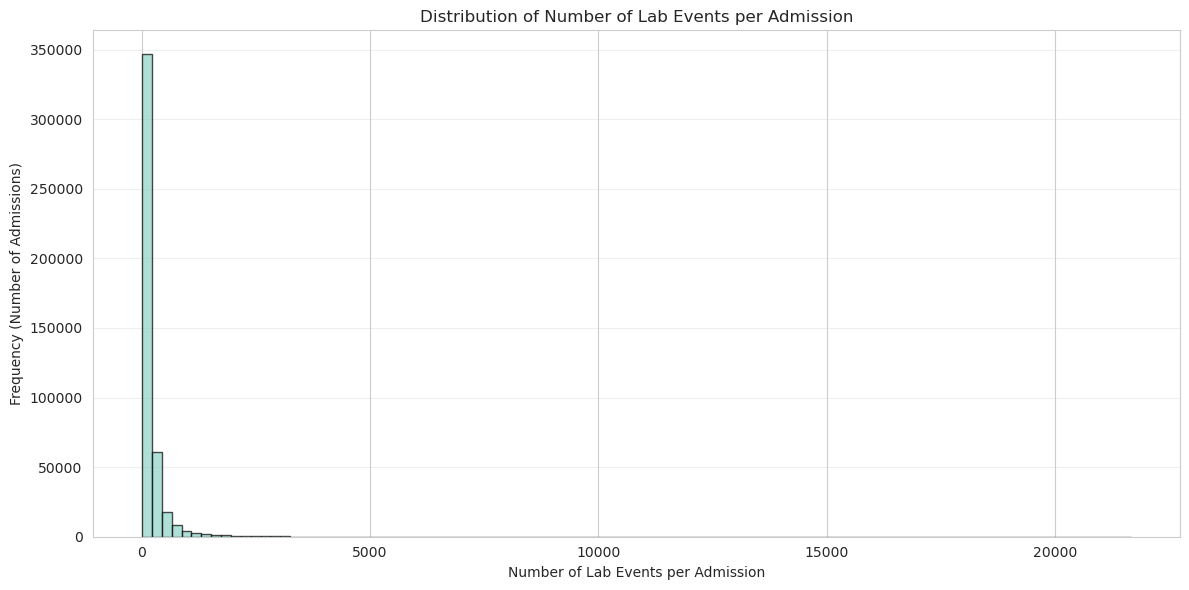

In [40]:
# Visualization 1: Histogram of lab events per admission
plt.figure(figsize=(12, 6))
plt.hist(lab_events_counts, bins=100, edgecolor='black', alpha=0.7)
plt.xlabel('Number of Lab Events per Admission')
plt.ylabel('Frequency (Number of Admissions)')
plt.title('Distribution of Number of Lab Events per Admission')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [41]:
# Get top 20 most frequent lab tests
top_20_labitems = sorted(itemid_frequency.items(), key=lambda x: x[1], reverse=True)[:20]

# Map itemids to labels
top_20_labels = []
top_20_counts = []
for itemid, count in top_20_labitems:
    label = labitem_map.get(itemid, f"Unknown ({itemid})")
    top_20_labels.append(label)
    top_20_counts.append(count)

print("\nTOP 20 MOST FREQUENT LAB TESTS:")
for i, (label, count) in enumerate(zip(top_20_labels, top_20_counts), 1):
    print(f"{i:2d}. {label:50s} - {count:,} occurrences")


TOP 20 MOST FREQUENT LAB TESTS:
 1. Potassium                                          - 2,648,172 occurrences
 2. Sodium                                             - 2,625,912 occurrences
 3. Chloride                                           - 2,601,418 occurrences
 4. Creatinine                                         - 2,587,046 occurrences
 5. Hematocrit                                         - 2,580,696 occurrences
 6. Urea Nitrogen                                      - 2,568,501 occurrences
 7. Bicarbonate                                        - 2,547,064 occurrences
 8. Anion Gap                                          - 2,541,356 occurrences
 9. Glucose                                            - 2,517,646 occurrences
10. Platelet Count                                     - 2,468,141 occurrences
11. Hemoglobin                                         - 2,442,997 occurrences
12. White Blood Cells                                  - 2,427,187 occurrences
13. MCHC           

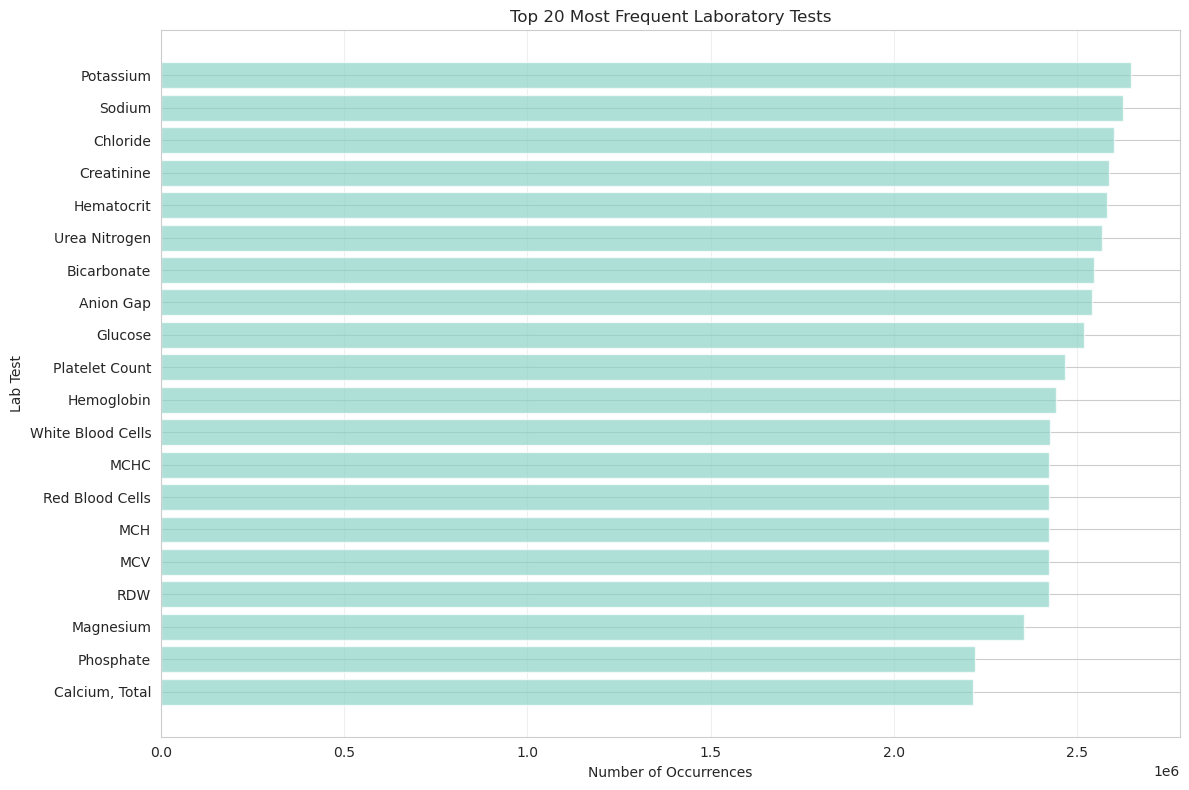

In [42]:
# Visualization 2: Horizontal bar chart of top 20 lab tests
plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_20_labels))
plt.barh(y_pos, top_20_counts, alpha=0.7)
plt.yticks(y_pos, top_20_labels)
plt.xlabel('Number of Occurrences')
plt.ylabel('Lab Test')
plt.title('Top 20 Most Frequent Laboratory Tests')
plt.gca().invert_yaxis()  # Highest at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## Section 2.1: Laboratory Test Repetition Frequency Analysis

Analyze how frequently each laboratory test is repeated per admission. This analysis helps distinguish between static features (measured once) and time-series features (measured repeatedly), which is essential for the P-CAFE/MDP framework.

Most tests are ordered only a handful of times (e.g., once at admission or a few scheduled repeats), while a smaller subset of critical monitoring labs can be ordered frequently, leading to a highly skewed repetition distribution.

In [43]:
# Analyze repetition frequency of laboratory tests per admission
print("\nAnalyzing laboratory test repetition frequency...")
print("This analysis counts how many times each specific test (itemid) appears within a single admission (hadm_id).")
print("Note: The repetition_counts data was already computed during the initial file read to avoid redundant processing.\n")
print(f"Total unique (admission, test) pairs: {len(repetition_counts):,}")


Analyzing laboratory test repetition frequency...
This analysis counts how many times each specific test (itemid) appears within a single admission (hadm_id).
Note: The repetition_counts data was already computed during the initial file read to avoid redundant processing.

Total unique (admission, test) pairs: 20,364,828


In [44]:
# Create a DataFrame from the repetition counts
print("\nCreating repetition_stats DataFrame...")
repetition_stats = pd.DataFrame([
    {'hadm_id': hadm_id, 'itemid': itemid, 'count': count}
    for (hadm_id, itemid), count in repetition_counts.items()
])

print(f"DataFrame created with {len(repetition_stats):,} rows")
print(f"\nFirst few rows:")
print(repetition_stats.head(10))


Creating repetition_stats DataFrame...
DataFrame created with 20,364,828 rows

First few rows:
      hadm_id  itemid  count
0  20010003.0   50861      2
1  20010003.0   50862      2
2  20010003.0   50863      2
3  20010003.0   50868     10
4  20010003.0   50878      2
5  20010003.0   50882     10
6  20010003.0   50885      2
7  20010003.0   50893      8
8  20010003.0   50902     10
9  20010003.0   50911      2


In [45]:
# Calculate summary statistics for repetitions per test per admission
mean_repetitions = repetition_stats['count'].mean()
median_repetitions = repetition_stats['count'].median()
max_repetitions = repetition_stats['count'].max()

print("=" * 80)
print("LABORATORY TEST REPETITION FREQUENCY STATISTICS")
print("=" * 80)
print(f"Mean repetitions per test per admission:   {mean_repetitions:.2f}")
print(f"Median repetitions per test per admission: {median_repetitions:.0f}")
print(f"Max repetitions per test per admission:    {max_repetitions}")
print("=" * 80)

LABORATORY TEST REPETITION FREQUENCY STATISTICS
Mean repetitions per test per admission:   4.15
Median repetitions per test per admission: 2
Max repetitions per test per admission:    1239


KeyboardInterrupt: 

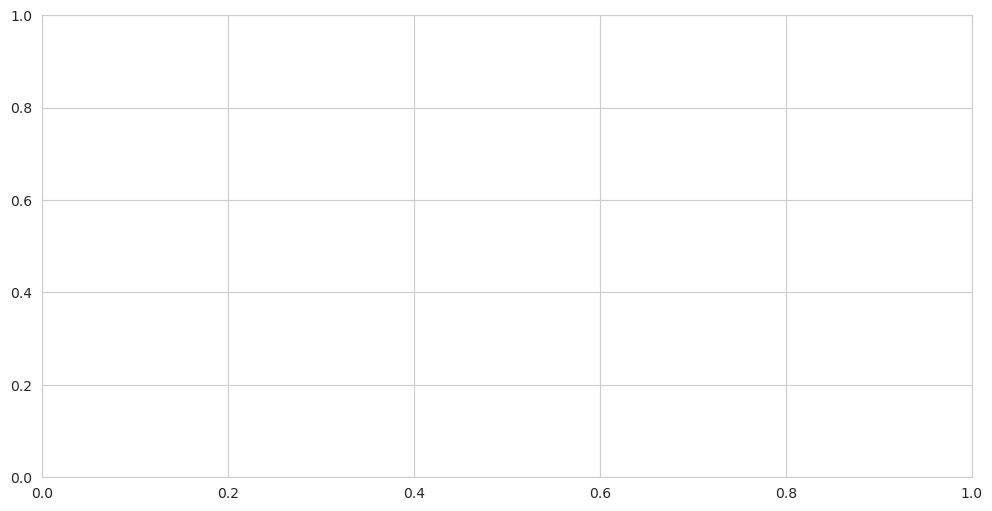

In [46]:
# Visualization: Histogram of repetitions per test per admission
plt.figure(figsize=(12, 6))
plt.hist(repetition_stats['count'], bins=100, edgecolor='black', alpha=0.7, color='mediumseagreen')
plt.xlabel('Number of Repetitions per Test per Admission')
plt.ylabel('Frequency (Log Scale)')
plt.title('Distribution of Laboratory Test Repetition Frequency per Admission')
plt.yscale('log')  # Use log scale for Y-axis due to highly skewed distribution
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Identify top 20 tests with highest average repetition count
print("\nCalculating average repetitions per test (itemid)...")
avg_repetitions_per_test = repetition_stats.groupby('itemid')['count'].mean().sort_values(ascending=False)
top_20_repeated = avg_repetitions_per_test.head(20)

# Join with d_labitems to get test names
top_20_repeated_df = pd.DataFrame({
    'itemid': top_20_repeated.index,
    'avg_repetitions': top_20_repeated.values
})

# Merge with d_labitems to get labels
top_20_repeated_df = top_20_repeated_df.merge(
    d_labitems_df[['itemid', 'label']], 
    on='itemid', 
    how='left'
)

# Fill missing labels
top_20_repeated_df['label'] = top_20_repeated_df.apply(
    lambda row: row['label'] if pd.notna(row['label']) else f"Unknown ({int(row['itemid'])})",
    axis=1
)

print("\nTOP 20 LABORATORY TESTS WITH HIGHEST AVERAGE REPETITION COUNT:")
print("=" * 80)
for i, row in top_20_repeated_df.iterrows():
    print(f"{i+1:2d}. {row['label']:50s} - Avg: {row['avg_repetitions']:.2f} repetitions/admission")
print("=" * 80)

In [ ]:
# Visualization: Bar chart of top 20 tests by average repetition count
plt.figure(figsize=(12, 8))
y_pos = np.arange(len(top_20_repeated_df))
plt.barh(y_pos, top_20_repeated_df['avg_repetitions'], alpha=0.7, color='mediumseagreen')
plt.yticks(y_pos, top_20_repeated_df['label'])
plt.xlabel('Average Number of Repetitions per Admission')
plt.ylabel('Laboratory Test')
plt.title('Top 20 Laboratory Tests by Average Repetition Count per Admission')
plt.gca().invert_yaxis()  # Highest at the top
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()